## PROJECT 1: Basic Neural Network - Housing Price Prediction
### Techniques: Dense layers, Forward propagation, Backpropagation, Loss functions

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# Generate synthetic housing data
np.random.seed(42)
n_samples = 1000

In [5]:
# Features: size, bedrooms, age, location_score
size = np.random.uniform(500, 3000, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age = np.random.uniform(0, 50, n_samples)
location = np.random.uniform(1, 10, n_samples)

In [6]:
# Price calculation with some noise
price = (size * 200 + bedrooms * 50000 - age * 1000 + 
         location * 10000 + np.random.normal(0, 50000, n_samples))

In [7]:
X = np.column_stack([size, bedrooms, age, location])
y = price

In [8]:
# Split and normalize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 800
Test samples: 200


In [11]:
# Build basic neural network
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,), name='hidden_1'),
    layers.Dense(32, activation='relu', name='hidden_2'),
    layers.Dense(1, name='output')
])

C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model
print("\nTraining the model...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Training the model...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 313308446720.0000 - mae: 531919.8750 - val_loss: 315436498944.0000 - val_mae: 531122.1875
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 313307267072.0000 - mae: 531918.8750 - val_loss: 315435057152.0000 - val_mae: 531120.8750
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 313305432064.0000 - mae: 531917.2500 - val_loss: 315432894464.0000 - val_mae: 531118.9375
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 313302745088.0000 - mae: 531914.8750 - val_loss: 315429519360.0000 - val_mae: 531116.0000
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 313298485248.0000 - mae: 531911.1250 - val_loss: 315424374784.0000 - val_mae: 531111.5000
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 313292226560.0000 - mae: 531905.6250 - val_loss: 315416739840.0000 - val_mae: 531105.0000
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 313282953216.0000 - mae:

In [15]:
# Evaluate
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Mean Absolute Error: ${test_mae:,.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 282364575744.0000 - mae: 504133.5625 

Test Mean Absolute Error: $504,133.56


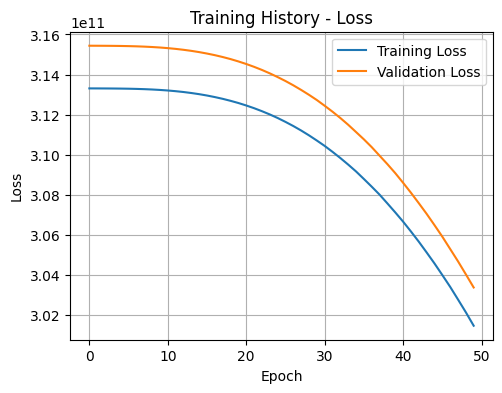

In [17]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training History - Loss')
plt.grid(True)

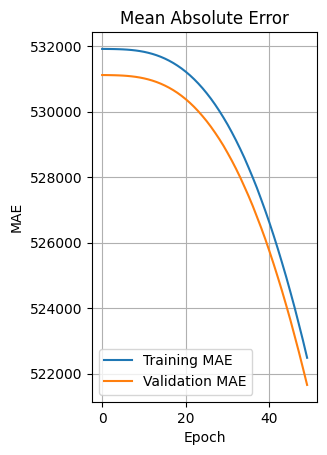

In [18]:
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Mean Absolute Error')
plt.grid(True)

In [19]:
plt.tight_layout()
plt.savefig('project1_training.png')
print("\nPlot saved as 'project1_training.png'")


Plot saved as 'project1_training.png'


<Figure size 640x480 with 0 Axes>

In [20]:
# Make predictions
predictions = model.predict(X_test_scaled[:5])
print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: ${y_test[i]:,.2f} | Predicted: ${predictions[i][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step

Sample Predictions:
Actual: $424,509.39 | Predicted: $3,831.81
Actual: $666,203.62 | Predicted: $11,336.70
Actual: $503,840.99 | Predicted: $8,908.12
Actual: $479,011.66 | Predicted: $9,305.47
Actual: $768,596.36 | Predicted: $19,551.93
